                  Skewness  Kurtosis
customerID        0.000000 -1.200000
gender           -0.019031 -2.000206
SeniorCitizen     0.000000  0.000000
Partner           0.067922 -1.995953
Dependents        0.875199 -1.234378
tenure            0.239540 -1.387372
PhoneService      0.000000  0.000000
MultipleLines     0.118719 -1.878378
InternetService   0.205423 -1.145505
OnlineSecurity    0.416985 -1.520966
OnlineBackup      0.182930 -1.684892
DeviceProtection  0.186847 -1.683207
TechSupport       0.402365 -1.535001
StreamingTV       0.028486 -1.722830
StreamingMovies   0.014657 -1.723523
Contract          0.630959 -1.272210
PaperlessBilling -0.375396 -1.859606
PaymentMethod    -0.170129 -1.211766
MonthlyCharges   -0.220524 -1.257260
TotalCharges      0.015857 -1.211641
Churn             1.063031 -0.870211


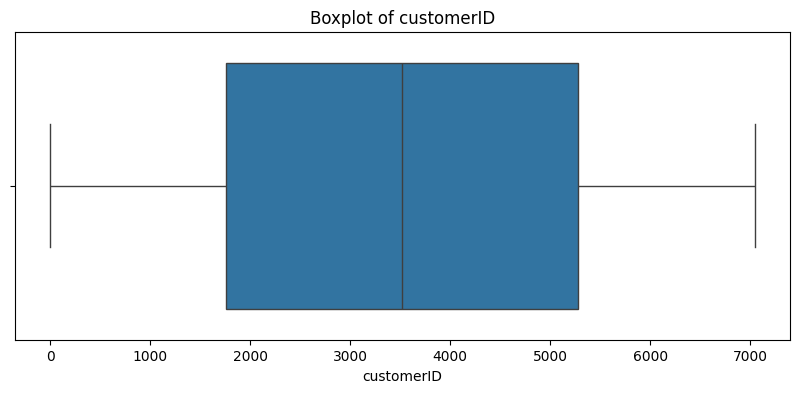

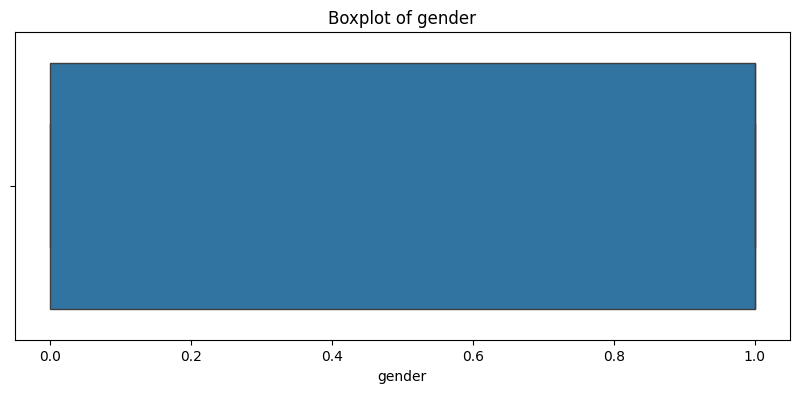

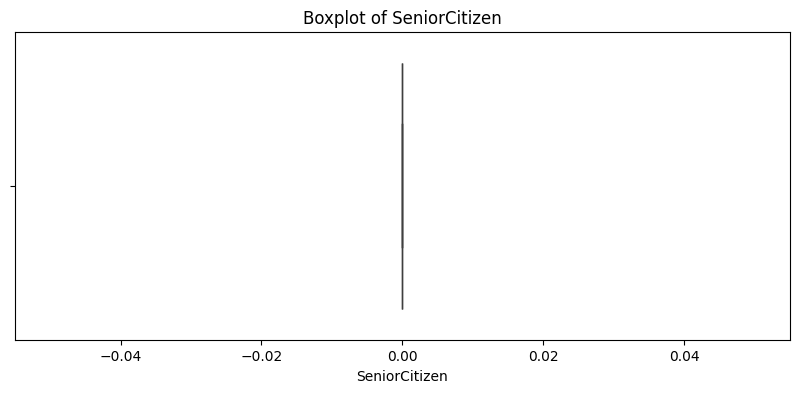

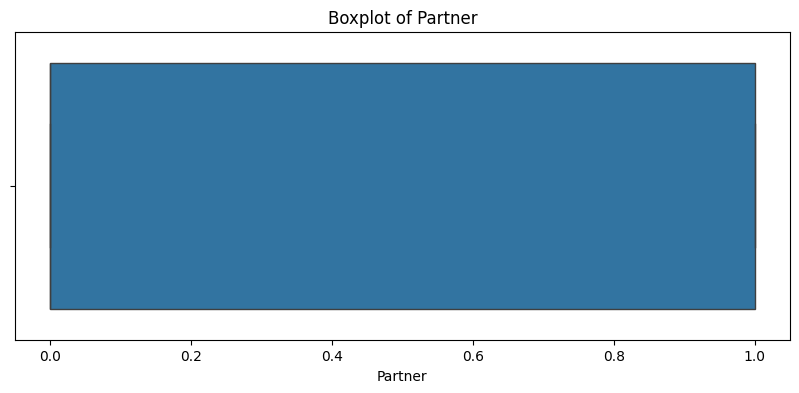

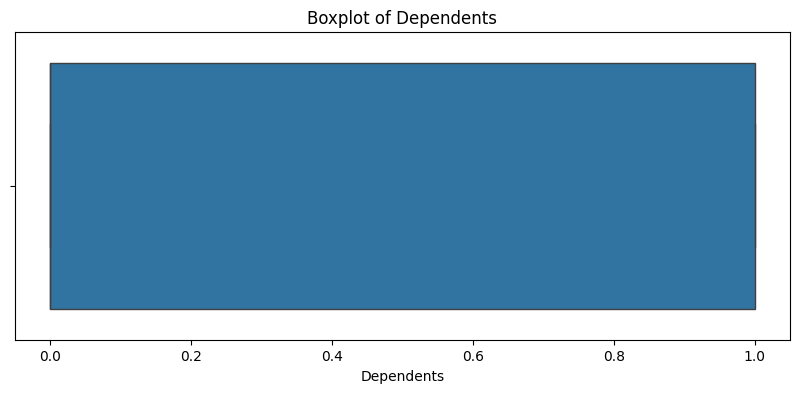

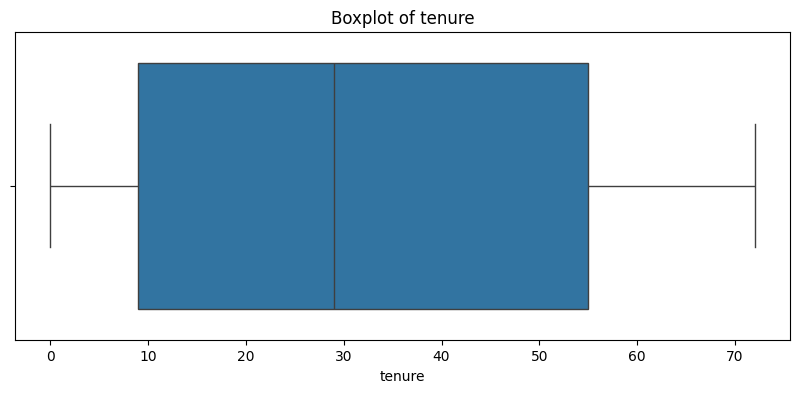

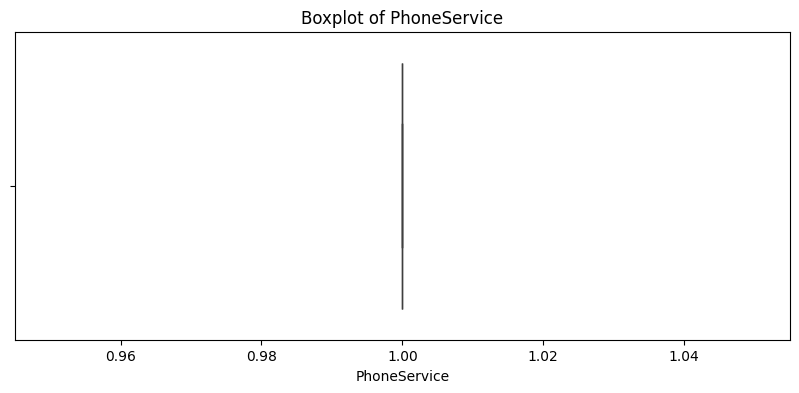

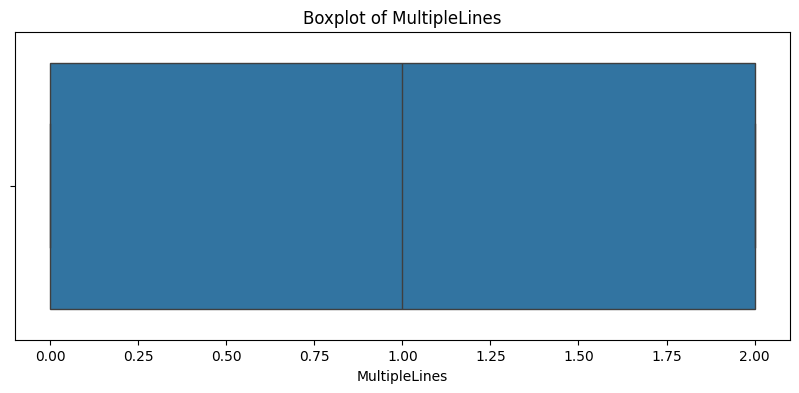

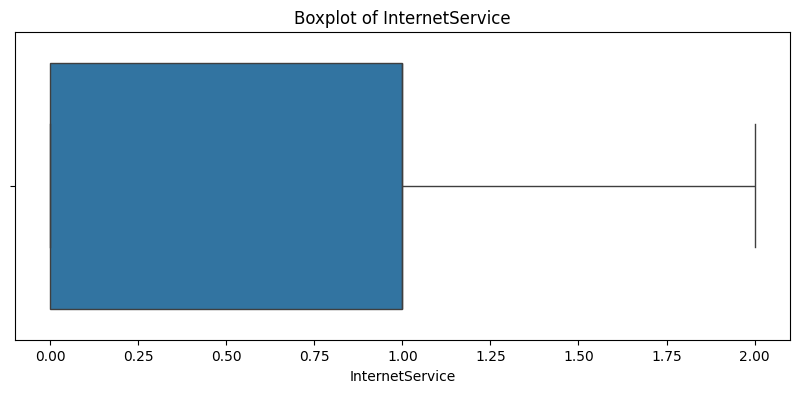

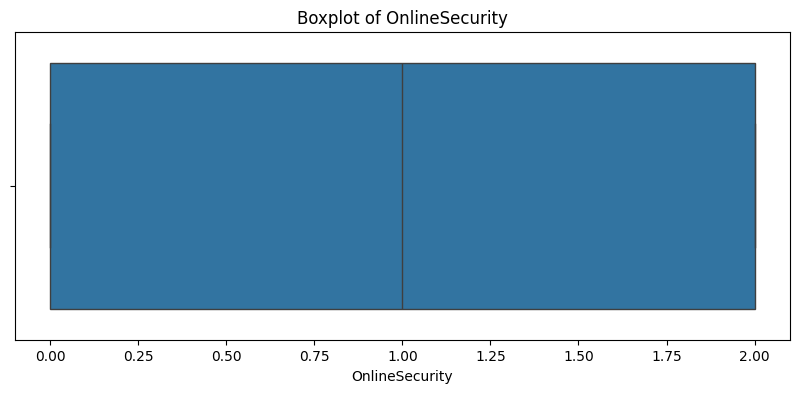

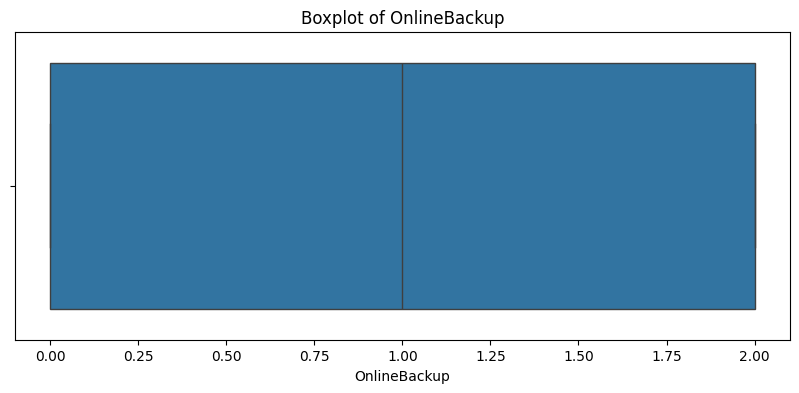

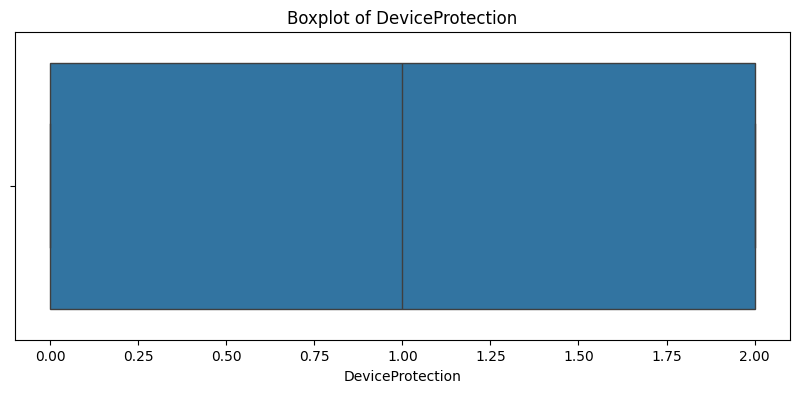

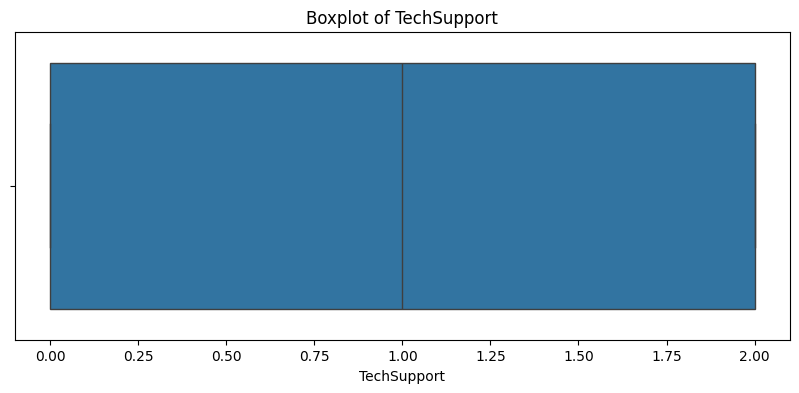

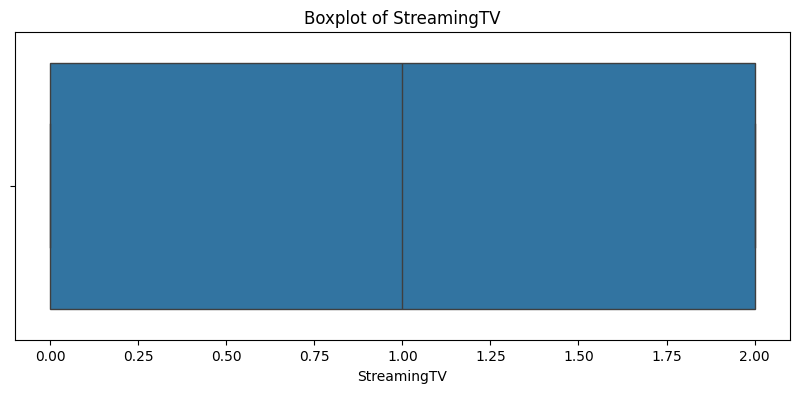

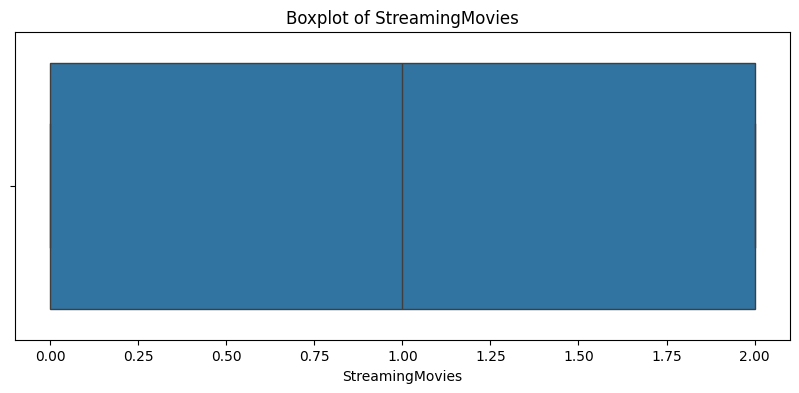

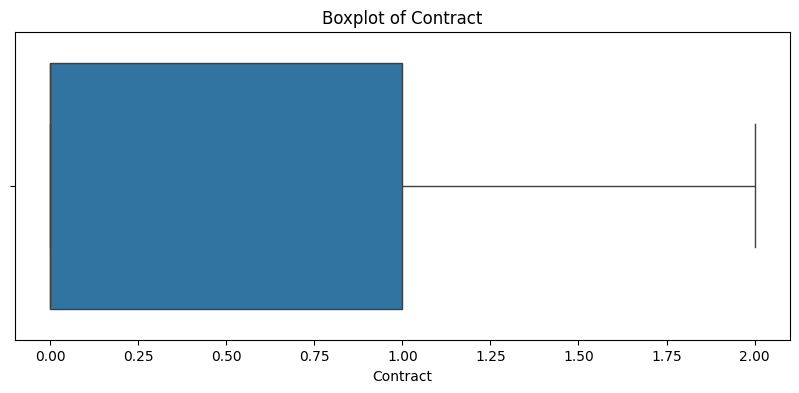

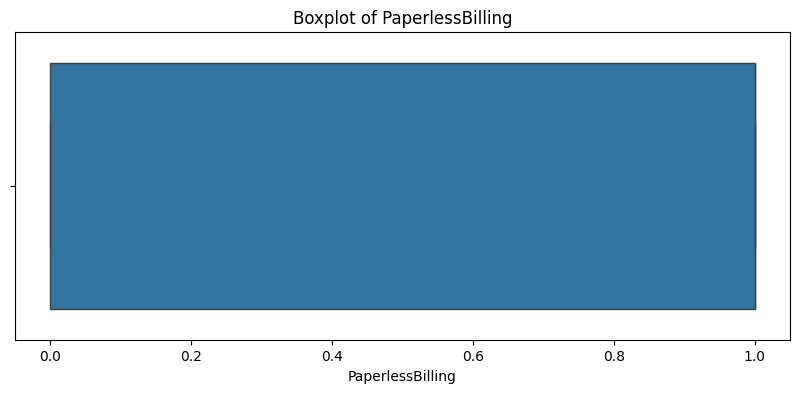

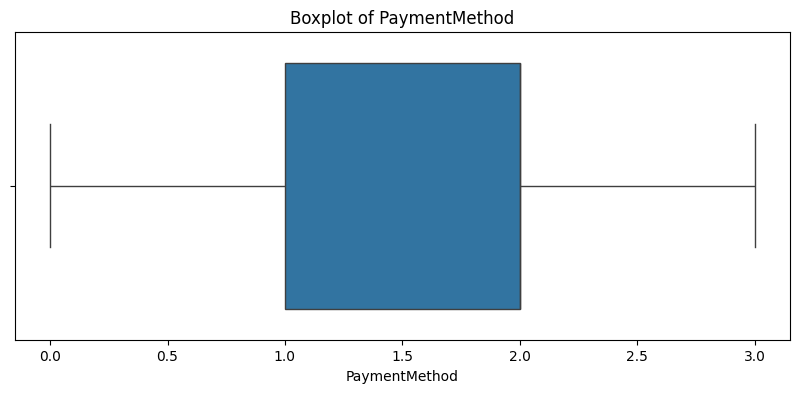

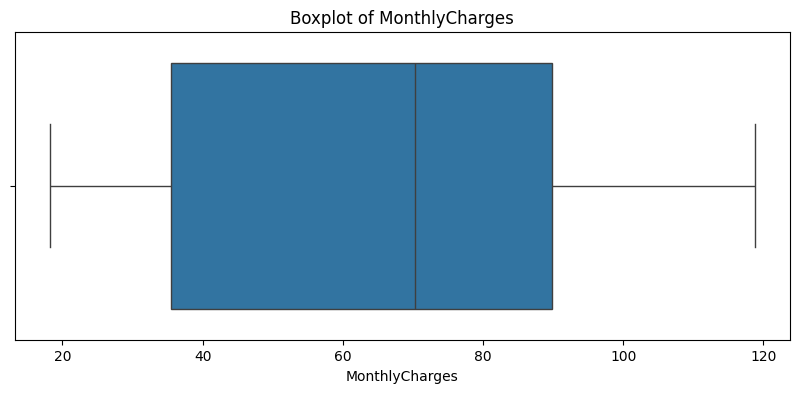

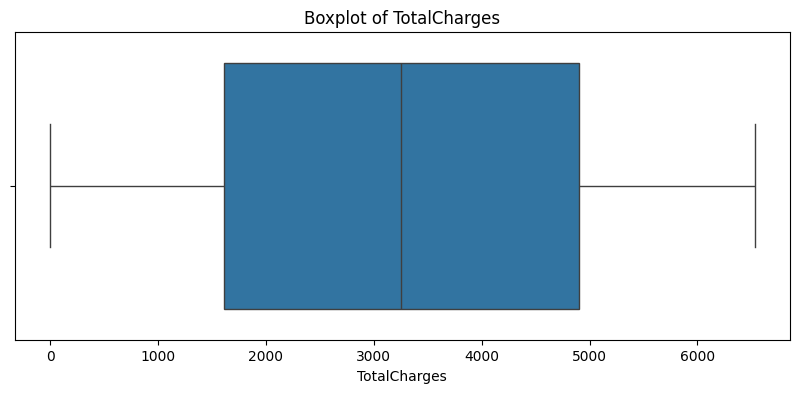

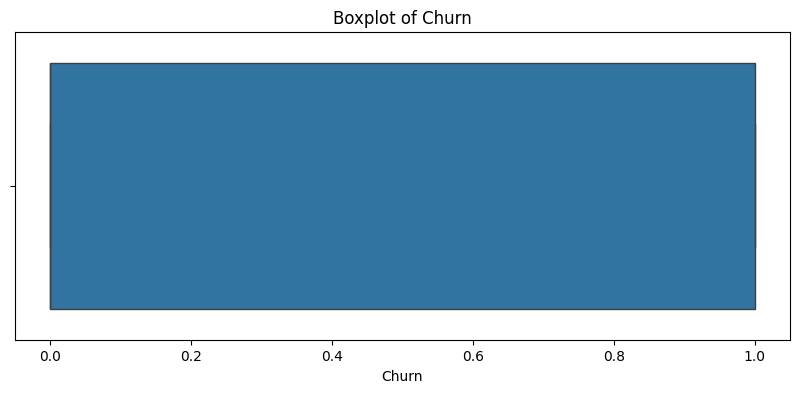

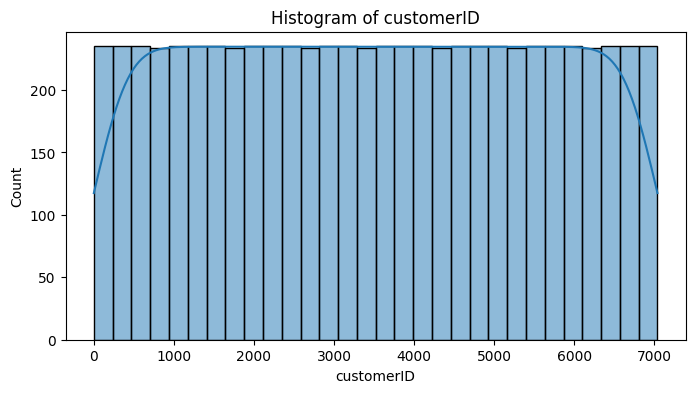

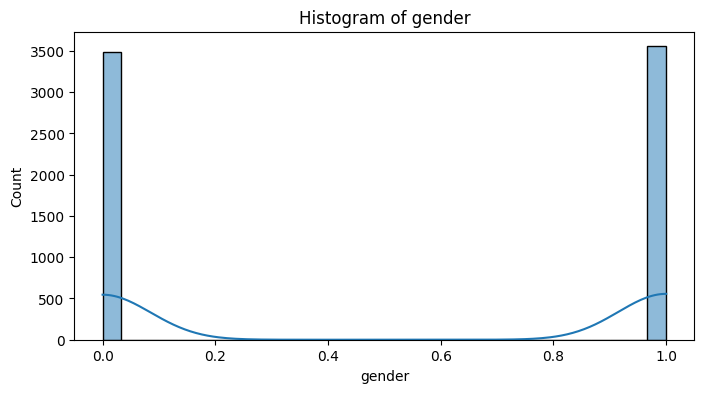

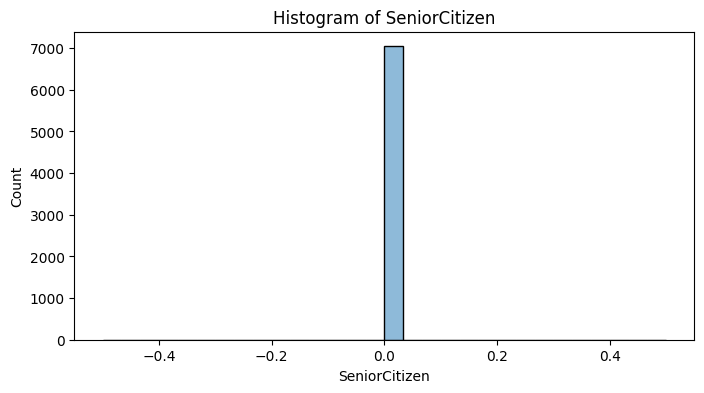

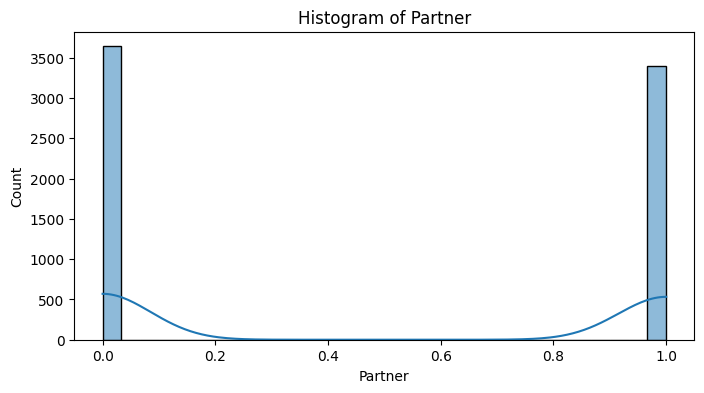

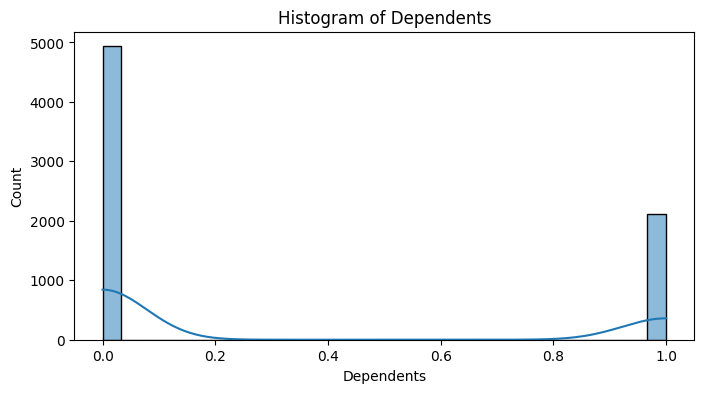

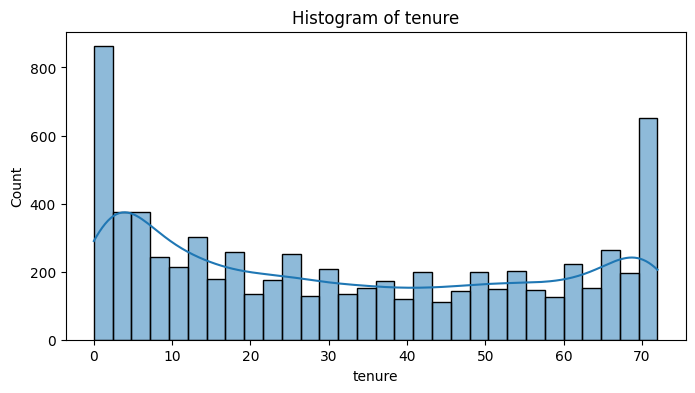

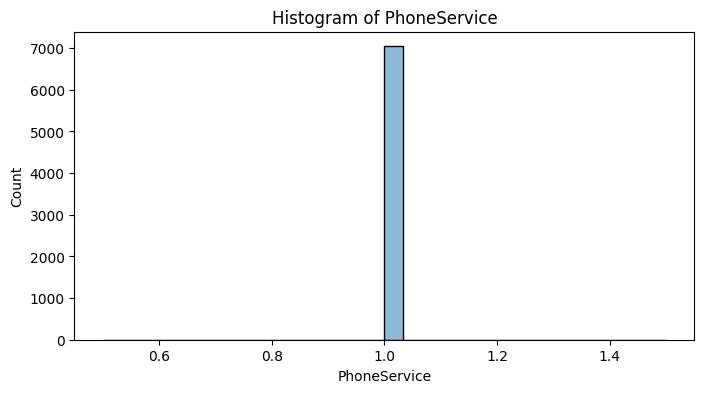

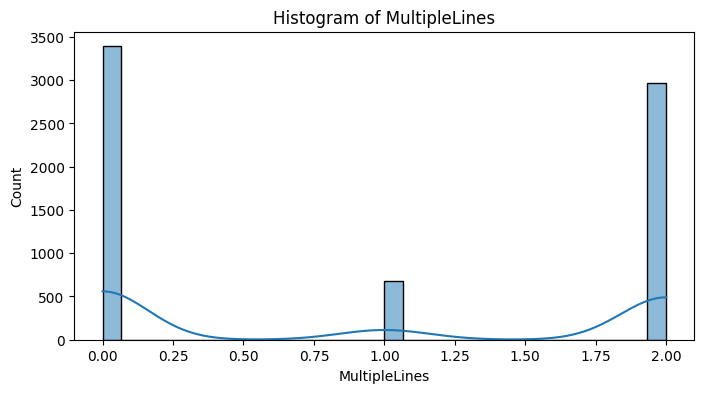

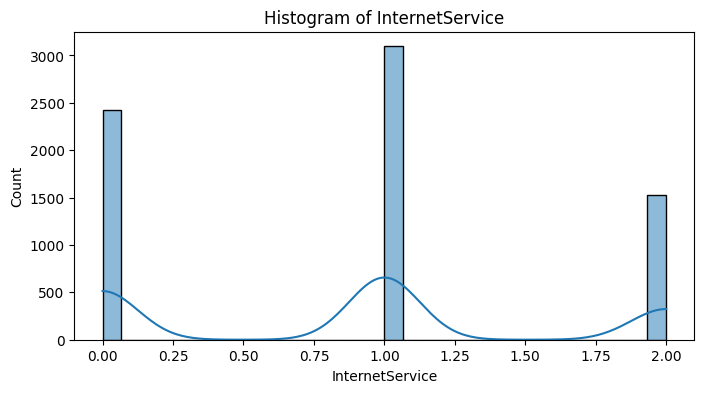

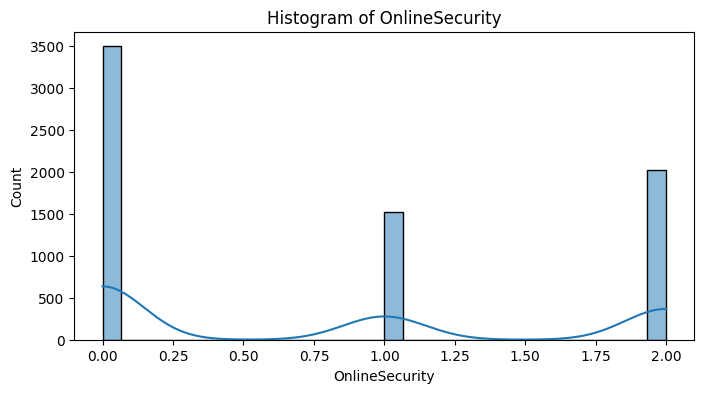

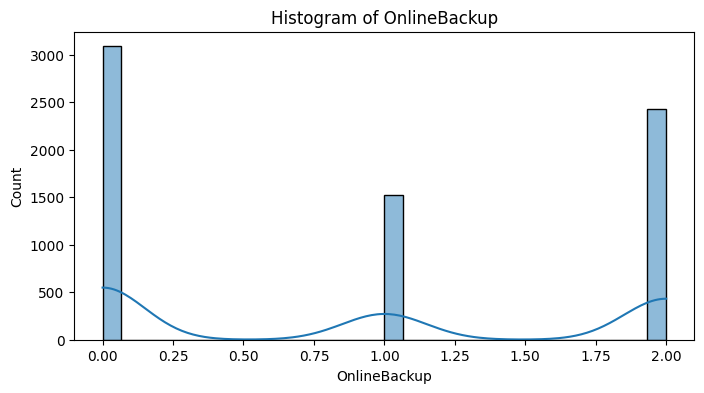

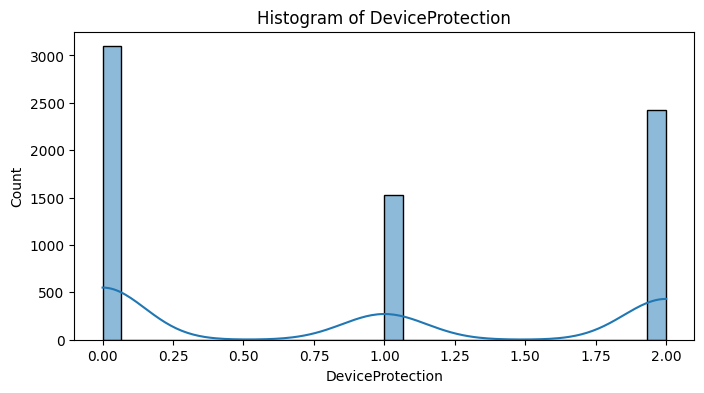

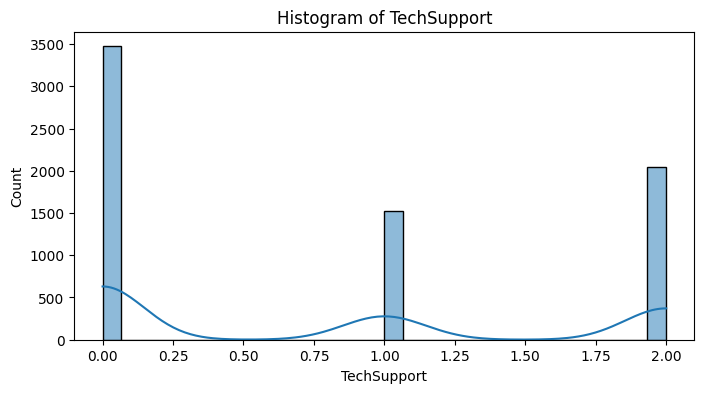

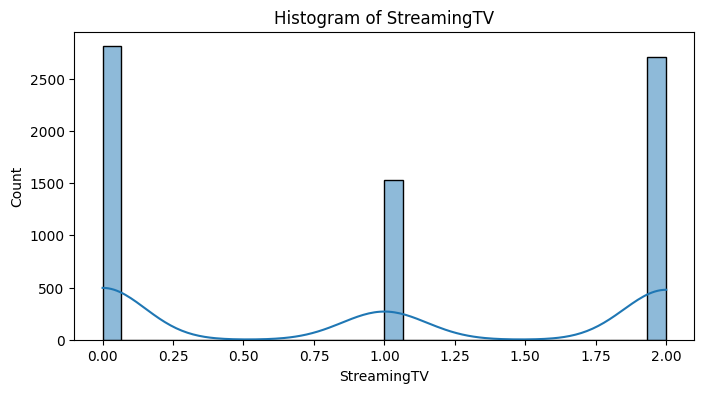

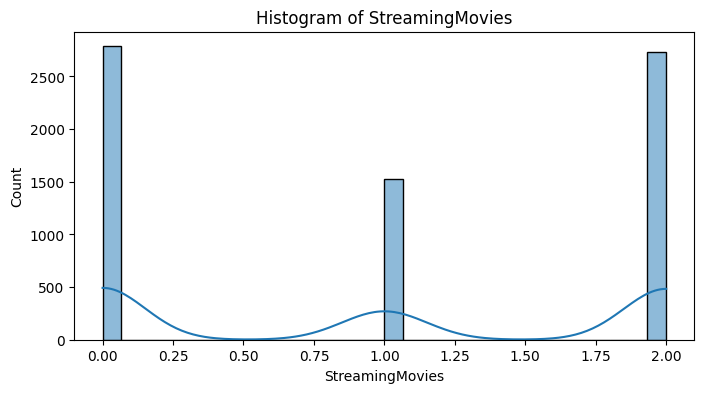

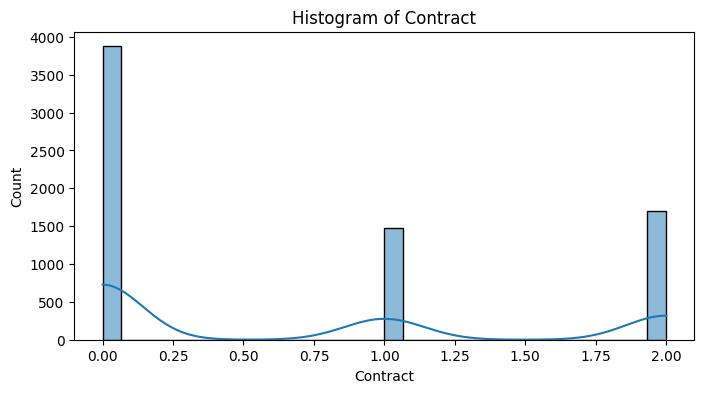

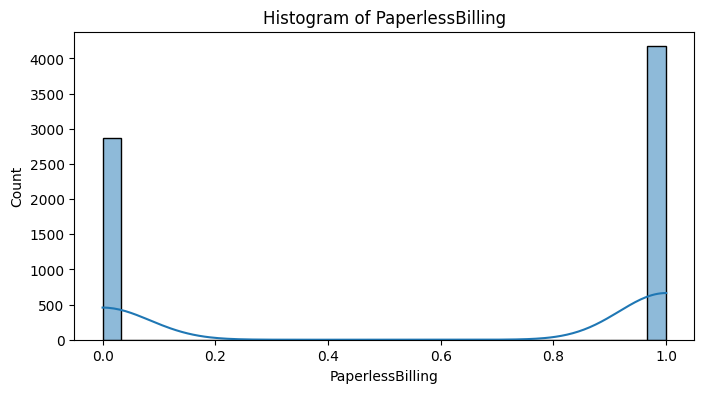

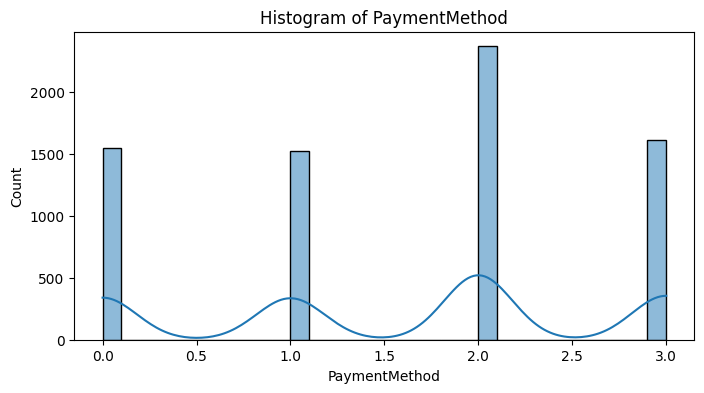

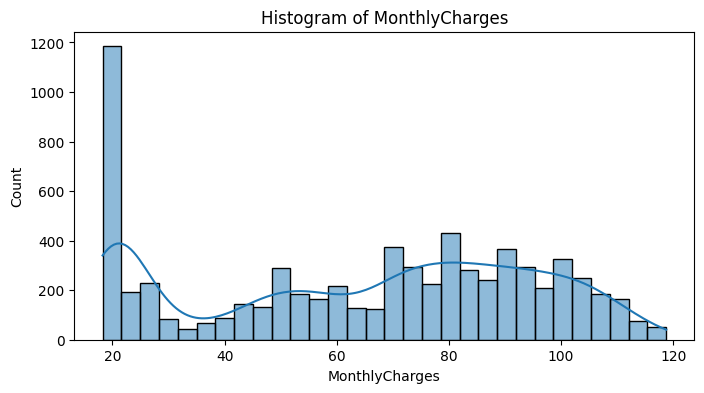

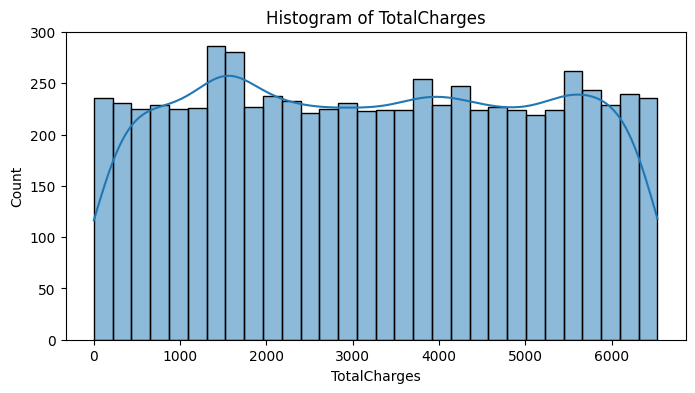

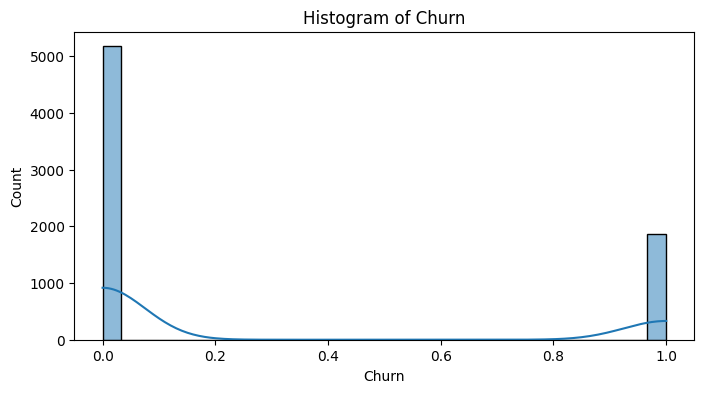

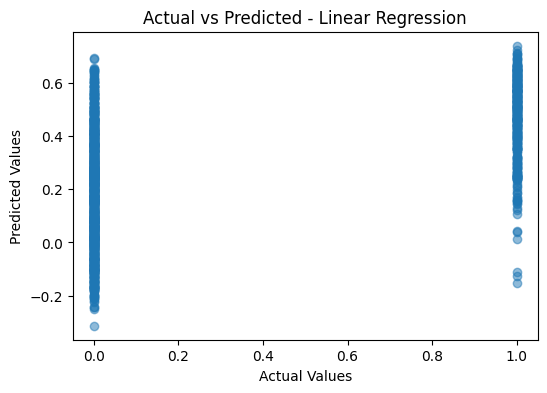

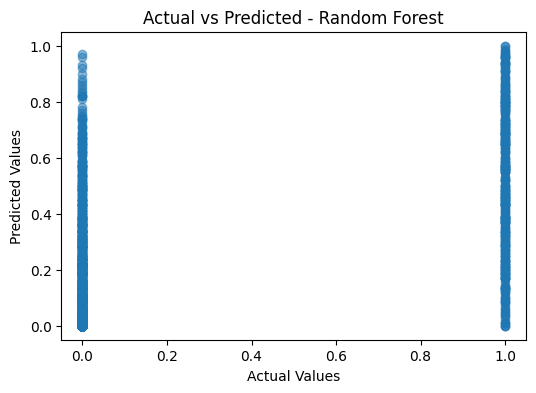

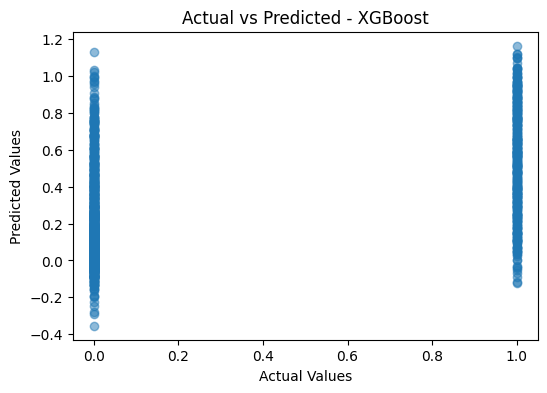

                        MSE       MAE      RMSE  R2 Score
Linear Regression  0.139164  0.308325  0.373047  0.285042
Random Forest      0.141422  0.272420  0.376062  0.273440
XGBoost            0.151124  0.280751  0.388746  0.223599


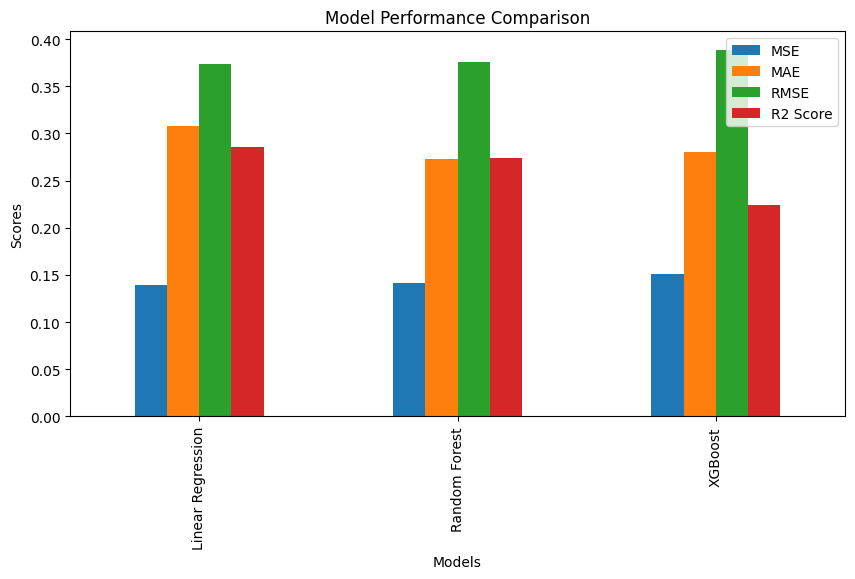

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix

# Load dataset
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'  # Update path after uploading
df = pd.read_csv(file_path)

# Convert categorical values to numerical
label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

# Identify numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Handle missing values
imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Outlier detection using IQR
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df[num_cols] = df[num_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

# Skewness and Kurtosis
skew_kurt_df = pd.DataFrame({'Skewness': df[num_cols].skew(), 'Kurtosis': df[num_cols].kurt()})
print(skew_kurt_df)

# Box Plot for numerical columns
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Histogram for numerical columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

# Prepare data for model training
X = df.drop(columns=['Churn'])  # Churn is the target column
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2 Score': r2_score(y_test, y_pred)
    }

    # Actual vs Predicted plot
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted - {name}')
    plt.show()

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

# Comparison Plot
results_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.legend()
plt.show()
